In [2]:
def create_typhoon_features(df):
    """
    创建增强的台风特征 - 改进版
    
    改进点：
    1. 使用非线性变换处理距离特征（sigmoid函数）
    2. 创建更有物理意义的综合影响指数
    3. 添加相对位置特征（台风相对于博罗站的位置）
    4. 使用标准化处理气压特征
    5. 创建强度累积特征（不仅看是否有台风，还看影响强度）
    """
    df = df.copy()
    
    # 1. 台风活跃标志（最基础的二值特征）
    df['台风活跃'] = (df['台风等级'] != 0).astype(int)
    
    # 2. 台风强度等级数值化
    def map_intensity(val):
        if pd.isna(val) or val == 0 or val == '0':
            return 0
        
        val_str = str(val).upper()
        
        if 'TD' in val_str or '热带低压' in val_str:
            return 1
        elif 'TS' in val_str or ('热带风暴' in val_str and '强' not in val_str):
            return 2
        elif 'STS' in val_str or '强热带风暴' in val_str:
            return 3
        elif 'STY' in val_str or '超强台风' in val_str:
            return 6
        elif 'TY' in val_str or ('台风' in val_str and '超强' not in val_str and '强' not in val_str):
            return 4
        elif '强台风' in val_str:
            return 5
        else:
            try:
                return float(val)
            except:
                return 0
    
    df['台风强度编码'] = df['台风强度'].apply(map_intensity)
    
    # 3. 【改进】台风距离影响权重（使用sigmoid函数进行非线性变换）
    # sigmoid函数将距离转换为0-1的影响权重
    # 距离250km时影响权重为0.5，距离越近权重越大
    df['台风距离影响'] = df.apply(
        lambda row: 1 / (1 + np.exp((row['距离博罗站'] - 250) / 50)) if row['距离博罗站'] > 0 else 0,
        axis=1
    )
    
    # 4. 【改进】台风综合影响指数（考虑风速、等级和距离的非线性综合影响）
    df['台风综合影响'] = df['风速'] * df['台风等级'] * df['台风距离影响']
    
    # 5. 【改进】台风风力等级（基于蒲福风级标准）
    def classify_wind(speed):
        if speed == 0:
            return 0
        elif speed < 17.2:
            return 1  # 热带低压
        elif speed < 24.5:
            return 2  # 热带风暴
        elif speed < 32.7:
            return 3  # 强热带风暴
        elif speed < 41.5:
            return 4  # 台风
        elif speed < 51.0:
            return 5  # 强台风
        else:
            return 6  # 超强台风
    
    df['风力等级'] = df['风速'].apply(classify_wind)
    
    # 6. 【改进】气压强度（标准化处理，相对于标准大气压的偏差）
    # 气压越低，台风越强，除以50进行标准化
    df['气压强度'] = df.apply(
        lambda row: (1013.25 - row['气压']) / 50 if row['气压'] > 0 else 0,
        axis=1
    )
    
    # 7. 台风持续时间特征
    df['台风持续天数'] = df['台风起始距今天数']
    
    # 8. 台风出现累积（滑动窗口 - 统计是否有台风）
    df['台风累积3天'] = df['台风活跃'].rolling(window=3, min_periods=1).sum()
    df['台风累积7天'] = df['台风活跃'].rolling(window=7, min_periods=1).sum()
    
    # 9. 【新增】台风影响强度累积（滑动窗口 - 统计台风影响强度的平均值）
    # 这个特征不仅看是否有台风，还考虑台风的实际影响强度
    df['台风强度累积3天'] = df['台风综合影响'].rolling(window=3, min_periods=1).mean()
    df['台风强度累积7天'] = df['台风综合影响'].rolling(window=7, min_periods=1).mean()
    
    # 10. 台风移动特征
    df['台风经度变化'] = df['台风经度'].diff().fillna(0)
    df['台风纬度变化'] = df['台风纬度'].diff().fillna(0)
    df['台风移动速度'] = np.sqrt(df['台风经度变化']**2 + df['台风纬度变化']**2)
    
    # 11. 【新增】台风相对位置特征（相对于博罗站的经纬度偏差）
    # 这样可以捕捉台风的方向信息
    boluo_lon = 114.2967
    boluo_lat = 23.15881
    df['台风相对经度'] = df['台风经度'] - boluo_lon
    df['台风相对纬度'] = df['台风纬度'] - boluo_lat
    
    # 12. 【新增】季节-台风交互特征
    df['date'] = pd.to_datetime(df['date'])
    df['月份'] = df['date'].dt.month
    df['是否台风季'] = df['月份'].isin([6, 7, 8, 9, 10]).astype(int)
    df['台风季节强度'] = df['台风综合影响'] * df['是否台风季']
    
    return df

# ================== 第二步：创建滞后特征 ==================

def create_lagged_features(df, target_column, lag_days=7, feature_type='baseline'):
    """
    创建前 lag_days 天的特征用于预测目标列，使用(T-1)格式命名
    """
    features = []
    labels = []
    
    # 定义台风相关列
    typhoon_base_cols = ['台风起始距今天数', '台风经度', '台风纬度', 
                         '台风等级', '台风强度', '风速', '气压', '距离博罗站']
    
    # 【修改】更新增强特征列表，与create_typhoon_features()函数创建的特征对应
    typhoon_enhanced_cols = [
        '台风活跃',                # 台风活跃标志
        '台风强度编码',            # 强度数值化
        '台风距离影响',            # 改进：sigmoid距离影响（原来是'台风距离倒数'）
        '台风综合影响',            # 改进：综合影响指数（原来是'台风影响指数'）
        '风力等级',                # 风力等级分类（原来是'风速等级'）
        '气压强度',                # 改进：标准化气压（原来是'气压差'）
        '台风持续天数',            # 新增：持续时间
        '台风累积3天',             # 活跃累积
        '台风累积7天',             # 活跃累积
        '台风强度累积3天',         # 新增：强度累积
        '台风强度累积7天',         # 新增：强度累积
        '台风经度变化',            # 移动特征
        '台风纬度变化',            # 移动特征
        '台风移动速度',            # 移动特征
        '台风相对经度',            # 新增：相对位置
        '台风相对纬度',            # 新增：相对位置
        '月份',                    # 季节特征
        '是否台风季',              # 新增：台风季标志
        '台风季节强度'             # 新增：季节交互（原来是'台风季节交互'）
    ]
    
    # 根据特征类型选择列
    exclude_cols = ['date', target_column]
    
    if feature_type == 'baseline':
        # 基准模型：排除所有台风相关特征
        exclude_cols.extend(typhoon_base_cols)
        exclude_cols.extend(typhoon_enhanced_cols)
    elif feature_type == 'with_typhoon':
        # 包含原始台风特征，排除增强特征和台风强度原始列（因为有字符串）
        exclude_cols.extend(typhoon_enhanced_cols)
        exclude_cols.append('台风强度')  # 排除原始的台风强度列，使用编码后的
    elif feature_type == 'with_typhoon_enhanced':
        # 包含所有特征，但排除原始台风强度列
        exclude_cols.append('台风强度')  # 排除原始的台风强度列
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    for i in range(len(df) - lag_days):
        feature = df[feature_cols].iloc[i:i + lag_days].values.flatten()
        label = df[target_column].iloc[i + lag_days]
        features.append(feature)
        labels.append(label)
    
    # 生成特征列名（T-1, T-2, ..., T-7格式）
    feature_columns = []
    for day in range(1, lag_days + 1):
        for col in feature_cols:
            feature_columns.append(f'{col}(T-{day})')
    
    features = pd.DataFrame(features, columns=feature_columns)
    labels = pd.Series(labels, name=target_column)
    
    return features, labels

创建台风增强特征...
台风活跃天数: 401
Comprehensive: -0.020 (p=0.6963)
Distance: 0.043 (p=0.3901)
Wind: -0.171 (p=0.0006)
Pressure: -0.090 (p=0.0723)
Accumulation: 0.199 (p=0.0001)

选择的台风事件日期: 2006-08-04 00:00:00
峰值流量: 4940.00 m³/s


C:\Users\Administrator\AppData\Local\Temp\ipykernel_31960\364651744.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Figure 8 已保存至: results/Figure8_typhoon_mechanism.png


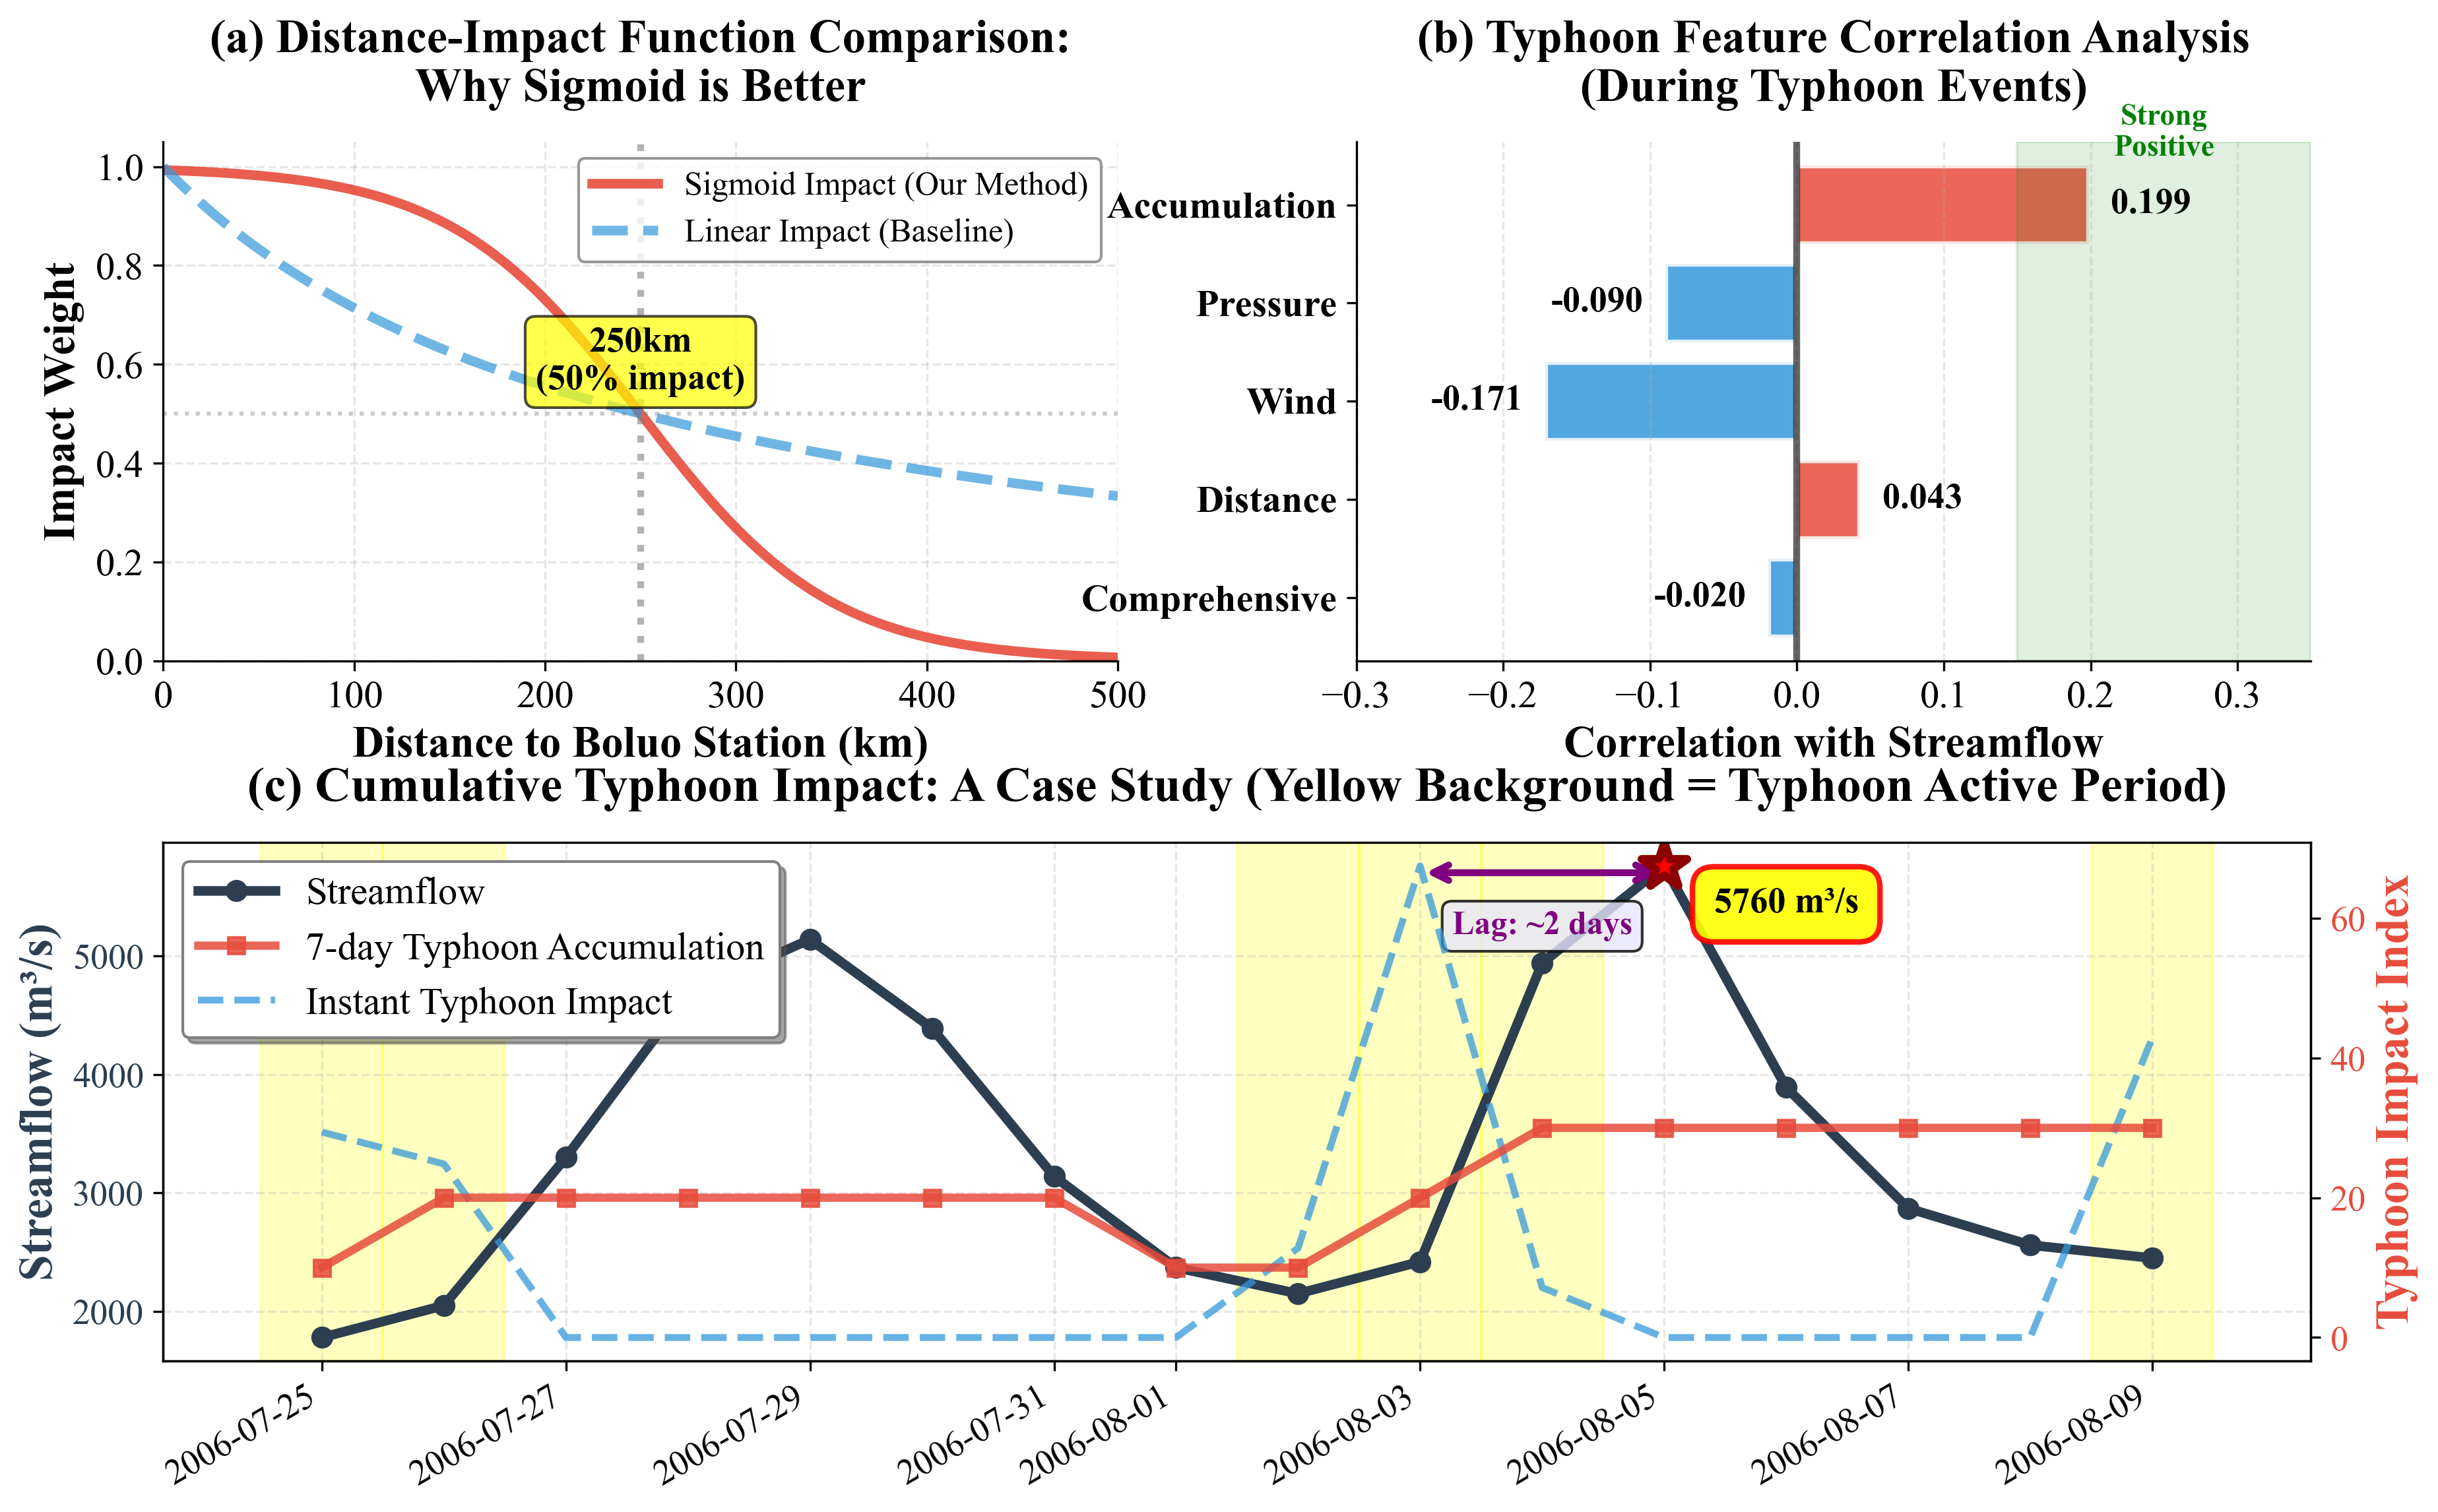

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
import os
from datetime import datetime, timedelta

# 设置字体
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["font.size"] = 14



def plot_typhoon_feature_analysis(
    data_file='../数据/typhoon_daily_boluo.csv',
    output_file='results/Figure8_typhoon_mechanism.png',
    figsize=(14, 8),
    dpi=300
):
    """
    绘制台风特征机制分析图
    布局：第一行2列（a、b），第二行1列占满（c）
    """
    # 读取数据
    df = pd.read_csv(data_file)
    df['date'] = pd.to_datetime(df['date'])
    
    # 创建增强特征
    print("创建台风增强特征...")
    df_enhanced = create_typhoon_features(df)
    
    # 创建图表 - 使用GridSpec
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25, height_ratios=[1, 1])
    
   
    # ==================== (a) 左上：Sigmoid距离影响函数 ====================
    ax1 = fig.add_subplot(gs[0, 0])
    
    # 生成距离范围
    distances = np.linspace(0, 500, 1000)
    
    # Sigmoid影响权重：1 / (1 + exp((d - 250) / 50))
    sigmoid_impact = 1 / (1 + np.exp((distances - 250) / 50))
    
    # 线性影响（简单倒数）
    linear_impact = np.where(distances > 0, 1 / (distances / 250 + 1), 1)
    
    # 绘制两种函数
    ax1.plot(distances, sigmoid_impact, linewidth=3.5, color='#e74c3c', 
            label='Sigmoid Impact (Our Method)', alpha=0.9)
    ax1.plot(distances, linear_impact, linewidth=3.5, color='#3498db', 
            linestyle='--', label='Linear Impact (Baseline)', alpha=0.7)
    
    # 标注关键点
    ax1.axvline(x=250, color='gray', linestyle=':', linewidth=2.5, alpha=0.6)
    ax1.text(250, 0.55, '250km\n(50% impact)', ha='center', fontsize=13, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontweight='bold')
    
    ax1.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.4)
    
    # 标注物理意义区域
    # ax1.axvspan(0, 100, alpha=0.12, color='red', label='High Impact Zone')
    # ax1.axvspan(100, 300, alpha=0.1, color='orange')
    # ax1.axvspan(300, 500, alpha=0.1, color='green', label='Low Impact Zone')
    
    ax1.set_xlabel('Distance to Boluo Station (km)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Impact Weight', fontsize=16, fontweight='bold')
    ax1.set_title('(a) Distance-Impact Function Comparison:\nWhy Sigmoid is Better',
                 fontsize=17, fontweight='bold', pad=15)
    ax1.legend(fontsize=12, loc='upper right', frameon=True, edgecolor='gray')
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlim(0, 500)
    ax1.set_ylim(0, 1.05)
    
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # ==================== (b) 右上：台风特征与径流的相关性分析 ====================
    ax2 = fig.add_subplot(gs[0, 1])
    
    # 筛选有台风活跃的日期
    typhoon_active = df_enhanced[df_enhanced['台风活跃'] == 1].copy()
    
    print(f"台风活跃天数: {len(typhoon_active)}")
    
    if len(typhoon_active) > 0:
        # 计算相关性（使用英文特征名）
        features_to_analyze = {
            '台风综合影响': 'Comprehensive',
            '台风距离影响': 'Distance',
            '风速': 'Wind',
            '气压强度': 'Pressure',
            '台风累积7天': 'Accumulation'
        }
        
        correlations = []
        feature_labels = []
        
        for feat_cn, feat_en in features_to_analyze.items():
            if feat_cn in typhoon_active.columns:
                corr, p_value = pearsonr(
                    typhoon_active[feat_cn].fillna(0),
                    typhoon_active['博罗站流量']
                )
                correlations.append(corr)
                feature_labels.append(feat_en)
                print(f"{feat_en}: {corr:.3f} (p={p_value:.4f})")
        
        # 绘制条形图
        colors = ['#e74c3c' if c > 0 else '#3498db' for c in correlations]
        bars = ax2.barh(range(len(correlations)), correlations, 
                       color=colors, alpha=0.85, edgecolor='white', linewidth=2)
        
        # 添加数值标签
        for i, (bar, corr) in enumerate(zip(bars, correlations)):
            x_pos = corr + (0.015 if corr > 0 else -0.015)
            ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                    f'{corr:.3f}',
                    ha='left' if corr > 0 else 'right',
                    va='center', fontsize=13, fontweight='bold')
        
        ax2.set_yticks(range(len(correlations)))
        ax2.set_yticklabels(feature_labels, fontsize=14, fontweight='bold')
        ax2.set_xlabel('Correlation with Streamflow', fontsize=16, fontweight='bold')
        ax2.set_title('(b) Typhoon Feature Correlation Analysis\n(During Typhoon Events)',
                     fontsize=17, fontweight='bold', pad=15)
        ax2.axvline(x=0, color='black', linewidth=2.5, alpha=0.6)
        ax2.grid(axis='x', linestyle='--', alpha=0.3)
        ax2.set_xlim(-0.3, 0.35)
        
        # 添加相关性强度标注
        ax2.axvspan(0.15, 0.35, alpha=0.12, color='green')
        ax2.text(0.25, len(correlations) - 0.5, 'Strong\nPositive', 
                ha='center', fontsize=11, color='green', fontweight='bold')
        
        
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
    
    # ==================== (c) 第二行占满：累积影响的时间序列案例 ====================
    ax3 = fig.add_subplot(gs[1, :])  # 占据第二行的两列
    
    # 选择一个典型台风事件
    if len(typhoon_active) > 0:
        max_flow_idx = typhoon_active['博罗站流量'].idxmax()
        event_date = typhoon_active.loc[max_flow_idx, 'date']
        
        print(f"\n选择的台风事件日期: {event_date}")
        print(f"峰值流量: {typhoon_active.loc[max_flow_idx, '博罗站流量']:.2f} m³/s")
        
        # 提取前后15天的数据
        start_date = event_date - pd.Timedelta(days=10)
        end_date = event_date + pd.Timedelta(days=5)
        
        event_data = df_enhanced[
            (df_enhanced['date'] >= start_date) &
            (df_enhanced['date'] <= end_date)
        ].copy()
        
        # 创建双y轴
        ax3_twin = ax3.twinx()
        
        # 绘制流量（左轴）
        line1 = ax3.plot(event_data['date'], event_data['博罗站流量'],
                        color='#2c3e50', linewidth=3.5, marker='o', markersize=7,
                        label='Streamflow', zorder=3)
        
        # 绘制台风累积影响（右轴）
        line2 = ax3_twin.plot(event_data['date'], event_data['台风累积7天']*10,
                             color='#e74c3c', linewidth=3, marker='s', markersize=6,
                             label='7-day Typhoon Accumulation', alpha=0.85, zorder=2)
        
        # 绘制即时影响（右轴）
        line3 = ax3_twin.plot(event_data['date'], event_data['台风综合影响'],
                             color='#3498db', linewidth=2.5, linestyle='--',
                             label='Instant Typhoon Impact', alpha=0.75, zorder=1)
        # ax3_twin.set_ylim(0,60)
        
        # 标注台风活跃期
        typhoon_days = event_data[event_data['台风活跃'] == 1]
        if len(typhoon_days) > 0:
            for _, row in typhoon_days.iterrows():
                ax3.axvspan(row['date'] - pd.Timedelta(hours=12),
                           row['date'] + pd.Timedelta(hours=12),
                           alpha=0.25, color='yellow', zorder=0)
        
        # 标注峰值
        peak_date = event_data.loc[event_data['博罗站流量'].idxmax(), 'date']
        peak_flow = event_data['博罗站流量'].max()
        ax3.scatter(peak_date , peak_flow, s=300, color='red',
                   edgecolors='darkred', linewidths=3, zorder=10, marker='*')
        ax3.text(peak_date+ timedelta(days=1), peak_flow * 0.92, f'{peak_flow:.0f} m³/s',
                ha='center', va='bottom', fontsize=13, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='yellow', alpha=0.9,
                         edgecolor='red', linewidth=2))
        
        # 标注滞后效应
        typhoon_peak_date = typhoon_days['date'].iloc[len(typhoon_days)//2] if len(typhoon_days) > 0 else None
        if typhoon_peak_date:
            lag_days = (peak_date - typhoon_peak_date).days
            
            # 只在滞后天数>0时绘制
            if lag_days > 0:
                ax3.annotate('', xy=(peak_date, peak_flow * 0.99),
                            xytext=(typhoon_peak_date, peak_flow * 0.99),
                            arrowprops=dict(arrowstyle='<->', lw=2.5, color='purple'))
                
                # 修复：正确计算两个Timestamp的中点
                mid_date = typhoon_peak_date + (peak_date - typhoon_peak_date) / 2
                
                ax3.text(mid_date, peak_flow * 0.9,
                        f'Lag: ~{lag_days} days',
                        ha='center', fontsize=12, fontweight='bold', color='purple',
                        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))
        
        # 设置标签
        ax3.set_ylabel('Streamflow (m³/s)', fontsize=17, fontweight='bold', color='#2c3e50')
        ax3_twin.set_ylabel('Typhoon Impact Index', fontsize=17, fontweight='bold', color='#e74c3c')
        ax3.set_title('(c) Cumulative Typhoon Impact: A Case Study (Yellow Background = Typhoon Active Period)',
                     fontsize=18, fontweight='bold', pad=15)
        
        # 合并图例
        lines = line1 + line2 + line3
        labels = [l.get_label() for l in lines]
        ax3.legend(lines, labels, fontsize=14, loc='upper left', frameon=True,
                  edgecolor='gray', fancybox=True, shadow=True)
        
        ax3.tick_params(axis='y', labelcolor='#2c3e50', labelsize=13)
        ax3_twin.tick_params(axis='y', labelcolor='#e74c3c', labelsize=13)
        ax3.grid(True, linestyle='--', alpha=0.3)
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=13)
        
        ax3.spines['top'].set_visible(False)
        
    
    # 调整布局
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # 保存
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Figure 8 已保存至: {output_file}")
    plt.show()

if __name__ == "__main__":
    plot_typhoon_feature_analysis()